

Name: Keerthi N

Reg No: 2411021240024

Course: Generative AI



# ASSIGNMENT 8





# Building a Variational Autoencoder and Visualising its Latent Space

## Objective

The objective of this assignment is to understand how a Variational Autoencoder (VAE) learns a structured latent space from the MNIST handwritten digit dataset.

In this assignment, a VAE is built with a 2-dimensional latent space. The model learns to encode MNIST images into a compact latent representation and then reconstruct the images using a decoder.

The learned latent space is visualised by plotting the encoded test images and colouring the points according to their digit labels. New digit images are also generated by selecting different points from the latent space and passing them through the decoder.

## Introduction

A Variational Autoencoder (VAE) is a type of generative neural network based on the basic Autoencoder architecture.

An Autoencoder has two main parts:

1. Encoder – compresses the input image into a smaller representation.
2. Decoder – reconstructs the original image from the smaller representation.

A VAE is different from a normal Autoencoder because the encoder learns a probability distribution instead of producing only one fixed representation.

For this assignment, the latent space has only two dimensions, z1 and z2. This makes it possible to visualise the latent representations on a 2D graph.

The VAE is trained using two important losses:

- Reconstruction Loss – measures how close the reconstructed image is to the original image.
- KL Divergence Loss – encourages the latent distribution to remain close to a standard normal distribution.

The total loss is:

Total Loss = Reconstruction Loss + KL Divergence Loss

## VAE Architecture

The VAE used in this assignment follows the architecture:

MNIST Image (28 × 28)
        ↓
Flatten
        ↓
Encoder
        ↓
Latent Mean (z_mean)
Latent Log Variance (z_log_var)
        ↓
Sampling
        ↓
2-Dimensional Latent Vector (z1, z2)
        ↓
Decoder
        ↓
Reconstructed Image (28 × 28)

The encoder converts each image into a 2-dimensional latent representation.

The decoder takes this 2-dimensional representation and attempts to generate the original handwritten digit.

The sampling step allows the VAE to generate new points in the latent space.

In [ ]:
# Import required libraries

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, Model

print("TensorFlow version:", tf.__version__)

# Check GPU availability
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Loading the MNIST Dataset

The MNIST dataset contains handwritten digits from 0 to 9.

The dataset contains:

- 60,000 training images
- 10,000 test images
- Each image has a size of 28 × 28 pixels
- There are 10 digit classes from 0 to 9

The pixel values are converted from the range 0–255 to the range 0–1 before training.

In [ ]:
# Load MNIST dataset

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print("Training images:", x_train.shape)
print("Training labels:", y_train.shape)
print("Test images:", x_test.shape)
print("Test labels:", y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training images: (60000, 28, 28)
Training labels: (60000,)
Test images: (10000, 28, 28)
Test labels: (10000,)


## Data Preprocessing

The MNIST images contain pixel values from 0 to 255.

Neural networks work better when the input values are scaled to a smaller range. Therefore, the pixel values are divided by 255 so that they are between 0 and 1.

The images are then flattened from 28 × 28 pixels into 784 values because the encoder uses Dense layers.

In [ ]:
# Normalize pixel values to the range 0 to 1

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Flatten each 28x28 image into 784 values

x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

print("Training data shape:", x_train.shape)
print("Test data shape:", x_test.shape)

Training data shape: (60000, 784)
Test data shape: (10000, 784)


## Visualising the MNIST Dataset Before Training

Before training the VAE, some MNIST images are displayed to understand the input data.

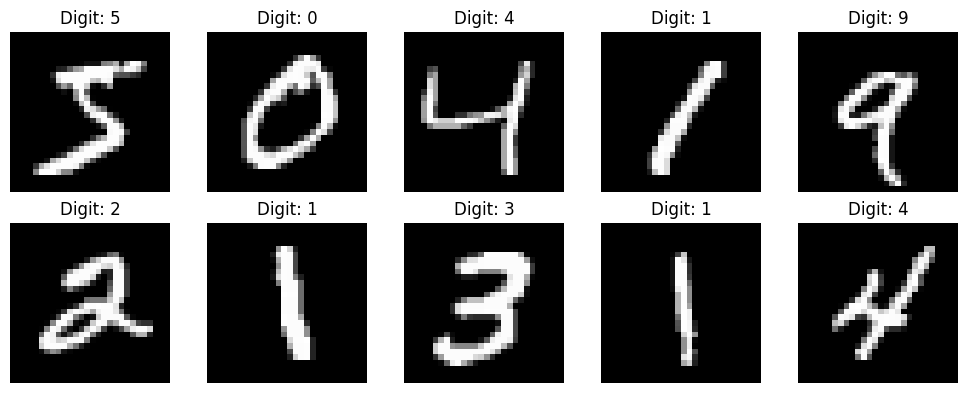

In [ ]:
# Display some original MNIST images before training

plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap="gray")
    plt.title(f"Digit: {y_train[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

## Defining the Latent Space

The latent space is intentionally kept at 2 dimensions.

The two dimensions are:

- z1
- z2

Using only two dimensions allows the learned representations to be plotted on a 2D graph and makes it easier to observe whether similar digits form clusters.

In [ ]:
# Latent space dimension

latent_dim = 2

print("Latent space dimensions:", latent_dim)

Latent space dimensions: 2


## Building the Encoder

The encoder receives a 784-dimensional MNIST image.

It processes the image through Dense layers and produces two outputs:

1. z_mean – the mean of the latent distribution
2. z_log_var – the logarithm of the variance of the latent distribution

These two values are used to sample a 2-dimensional latent vector.

In [ ]:
# Encoder

encoder_inputs = layers.Input(shape=(784,), name="encoder_input")

x = layers.Dense(256, activation="relu")(encoder_inputs)
x = layers.Dense(128, activation="relu")(x)

z_mean = layers.Dense(latent_dim, name="z_mean")(x)
z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)

encoder = Model(
    encoder_inputs,
    [z_mean, z_log_var],
    name="encoder"
)

encoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 784)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │    200,960 │ encoder_input[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │     32,896 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 2)         │        258 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 2)         │        258 │ dense_1[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 234,372 (915.52 KB)

 Trainable params: 234,372 (915.52 KB)

 Non-trainable params: 0 (0.00 B)

## Sampling the Latent Vector

The VAE does not directly use only the mean value.

Instead, a random value is sampled from the learned distribution.

The sampling equation is:

z = z_mean + exp(0.5 × z_log_var) × epsilon

where epsilon is random noise sampled from a standard normal distribution.

This process is called the reparameterization trick.

In [ ]:
# Sampling layer

class Sampling(layers.Layer):

    def call(self, inputs):
        z_mean, z_log_var = inputs

        epsilon = tf.random.normal(
            shape=tf.shape(z_mean)
        )

        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

## Building the Decoder

The decoder takes the 2-dimensional latent vector as input.

It passes this vector through Dense layers and produces 784 output values.

The output is reshaped back into a 28 × 28 image.

Therefore, the decoder converts a point in the latent space into a generated handwritten digit.

In [ ]:
# Decoder

latent_inputs = layers.Input(shape=(latent_dim,), name="latent_input")

x = layers.Dense(128, activation="relu")(latent_inputs)
x = layers.Dense(256, activation="relu")(x)

decoder_outputs = layers.Dense(
    784,
    activation="sigmoid",
    name="decoder_output"
)(x)

decoder = Model(
    latent_inputs,
    decoder_outputs,
    name="decoder"
)

decoder.summary()

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ latent_input (InputLayer)       │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_output (Dense)          │ (None, 784)            │       201,488 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 234,896 (917.56 KB)

 Trainable params: 234,896 (917.56 KB)

 Non-trainable params: 0 (0.00 B)

## Building the Variational Autoencoder

The complete VAE combines the encoder, sampling layer and decoder.

The input image is first encoded into a mean and variance. A latent vector is sampled from this distribution, and the decoder reconstructs the original image.

In [ ]:
# Build the complete VAE

class VAE(Model):

    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)

        self.encoder = encoder
        self.decoder = decoder
        self.sampling = Sampling()

        self.total_loss_tracker = tf.keras.metrics.Mean(
            name="total_loss"
        )

        self.reconstruction_loss_tracker = tf.keras.metrics.Mean(
            name="reconstruction_loss"
        )

        self.kl_loss_tracker = tf.keras.metrics.Mean(
            name="kl_loss"
        )

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker
        ]

    def train_step(self, data):

        if isinstance(data, tuple):
            data = data[0]

        with tf.GradientTape() as tape:

            z_mean, z_log_var = self.encoder(data)

            z = self.sampling(
                (z_mean, z_log_var)
            )

            reconstruction = self.decoder(z)

            # Reconstruction loss
            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(
                    tf.keras.backend.binary_crossentropy(
                        data,
                        reconstruction
                    ),
                    axis=1
                )
            )

            # KL divergence loss
            kl_loss = -0.5 * tf.reduce_mean(
                tf.reduce_sum(
                    1 + z_log_var
                    - tf.square(z_mean)
                    - tf.exp(z_log_var),
                    axis=1
                )
            )

            # Total loss
            total_loss = reconstruction_loss + kl_loss

        gradients = tape.gradient(
            total_loss,
            self.trainable_weights
        )

        self.optimizer.apply_gradients(
            zip(gradients, self.trainable_weights)
        )

        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(
            reconstruction_loss
        )
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss":
                self.reconstruction_loss_tracker.result(),
            "kl_loss":
                self.kl_loss_tracker.result()
        }

## Compiling the VAE

The Adam optimizer is used to train the VAE.

The model will learn by minimizing the total loss, which consists of reconstruction loss and KL divergence loss.

In [ ]:
# Create VAE

vae = VAE(
    encoder,
    decoder,
    name="mnist_vae"
)

# Compile the model

vae.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    )
)

print("VAE created successfully.")

VAE created successfully.


## Training the VAE

The VAE is trained for approximately 20 epochs using the MNIST training dataset.

During training, the model records:

- Total Loss
- Reconstruction Loss
- KL Divergence Loss

The reconstruction loss measures how accurately the decoder reconstructs the original image.

The KL divergence loss encourages the latent distribution to remain close to a standard normal distribution.

In [ ]:
# Train the VAE

EPOCHS = 20
BATCH_SIZE = 256

history = vae.fit(
    x_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    verbose=1
)

Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - kl_loss: 6.3442 - loss: 211.3420 - reconstruction_loss: 204.9978 
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - kl_loss: 4.4582 - loss: 173.7939 - reconstruction_loss: 169.3358
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - kl_loss: 4.7502 - loss: 167.5772 - reconstruction_loss: 162.8271
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - kl_loss: 4.9220 - loss: 164.3405 - reconstruction_loss: 159.4186
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - kl_loss: 5.1335 - loss: 161.3002 - reconstruction_loss: 156.1667
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - kl_loss: 5.3361 - loss: 158.5735 - reconstruction_loss: 153.2374
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - kl_loss: 5.5142 - loss: 156.2663 - reconstruction_loss: 150.7521
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - kl_loss: 5.6500 - loss: 154.5744 - reconstruction_loss: 148.9245
Epoch 9/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms

## Final Training Loss

The final values of the total loss, reconstruction loss and KL divergence loss are displayed below.

In [ ]:
# Display final losses

final_total_loss = history.history["loss"][-1]
final_reconstruction_loss = history.history["reconstruction_loss"][-1]
final_kl_loss = history.history["kl_loss"][-1]

print("Final Total Loss:", final_total_loss)
print("Final Reconstruction Loss:", final_reconstruction_loss)
print("Final KL Divergence Loss:", final_kl_loss)

Final Total Loss: 145.41334533691406
Final Reconstruction Loss: 139.1150665283203
Final KL Divergence Loss: 6.298323154449463


## Reconstruction Loss During Training

The reconstruction loss shows how well the VAE learns to reproduce the original MNIST images.

A decreasing reconstruction loss indicates that the decoder is learning to reconstruct the input images more accurately.

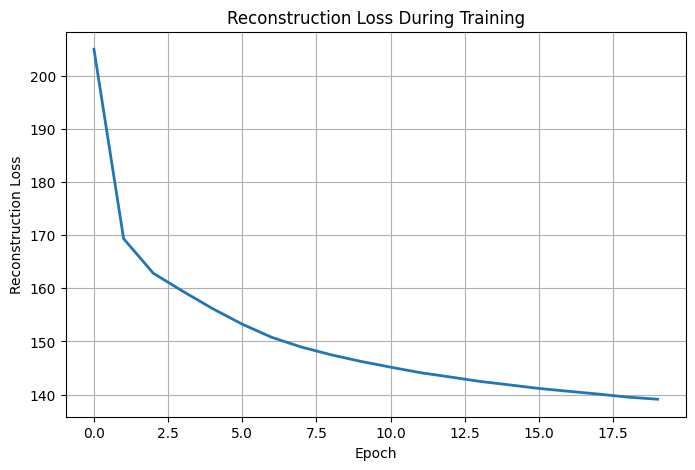

In [ ]:
# Plot reconstruction loss

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["reconstruction_loss"],
    linewidth=2
)

plt.xlabel("Epoch")
plt.ylabel("Reconstruction Loss")
plt.title("Reconstruction Loss During Training")
plt.grid(True)

plt.show()

## KL Divergence Loss During Training

KL divergence controls the structure of the latent space.

It encourages the learned latent distribution to remain close to a standard normal distribution.

The KL divergence loss is recorded during every training epoch.

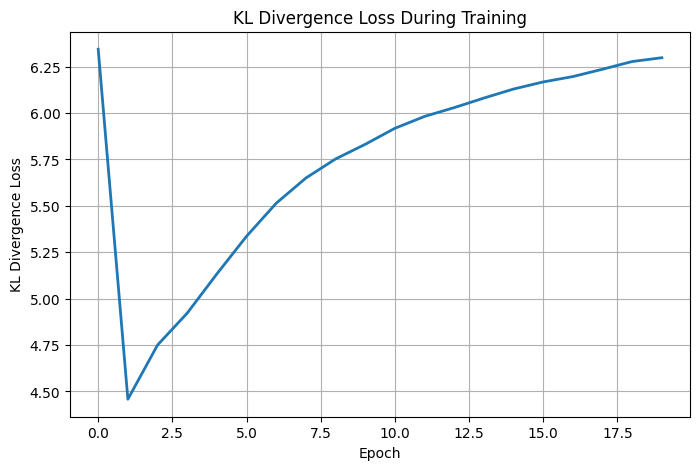

In [ ]:
# Plot KL divergence loss

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["kl_loss"],
    linewidth=2
)

plt.xlabel("Epoch")
plt.ylabel("KL Divergence Loss")
plt.title("KL Divergence Loss During Training")
plt.grid(True)

plt.show()

## Total Loss During Training

The total loss is the combination of reconstruction loss and KL divergence loss.

Total Loss = Reconstruction Loss + KL Divergence Loss

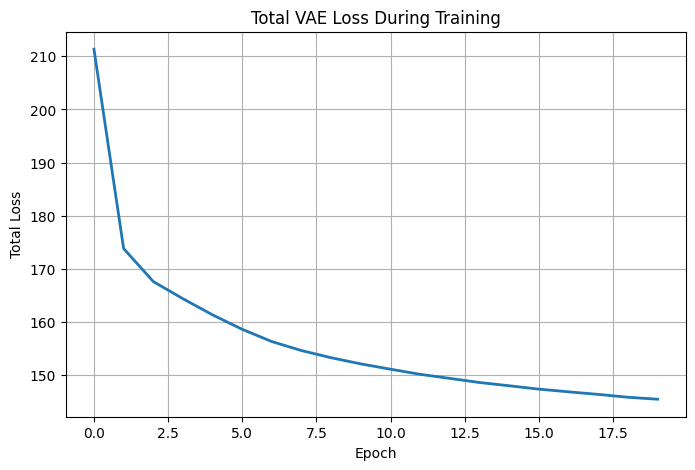

In [ ]:
# Plot total loss

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    linewidth=2
)

plt.xlabel("Epoch")
plt.ylabel("Total Loss")
plt.title("Total VAE Loss During Training")
plt.grid(True)

plt.show()

## Encoding the Test Images

After training, the 10,000 MNIST test images are passed through the encoder.

The encoder produces a 2-dimensional latent representation for every test image.

These representations are used to visualise the learned latent space.

In [ ]:
# Encode test images

z_mean_test, z_log_var_test = encoder.predict(
    x_test,
    batch_size=256,
    verbose=1
)

print("Encoded latent representation shape:")
print(z_mean_test.shape)

40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step
Encoded latent representation shape:
(10000, 2)


## Visualising the 2D Latent Space

The encoded test images are plotted using their two latent dimensions:

- Horizontal axis = z1
- Vertical axis = z2

The points are coloured according to their original digit labels from 0 to 9.

This helps us observe whether similar digits form groups or clusters in the latent space.

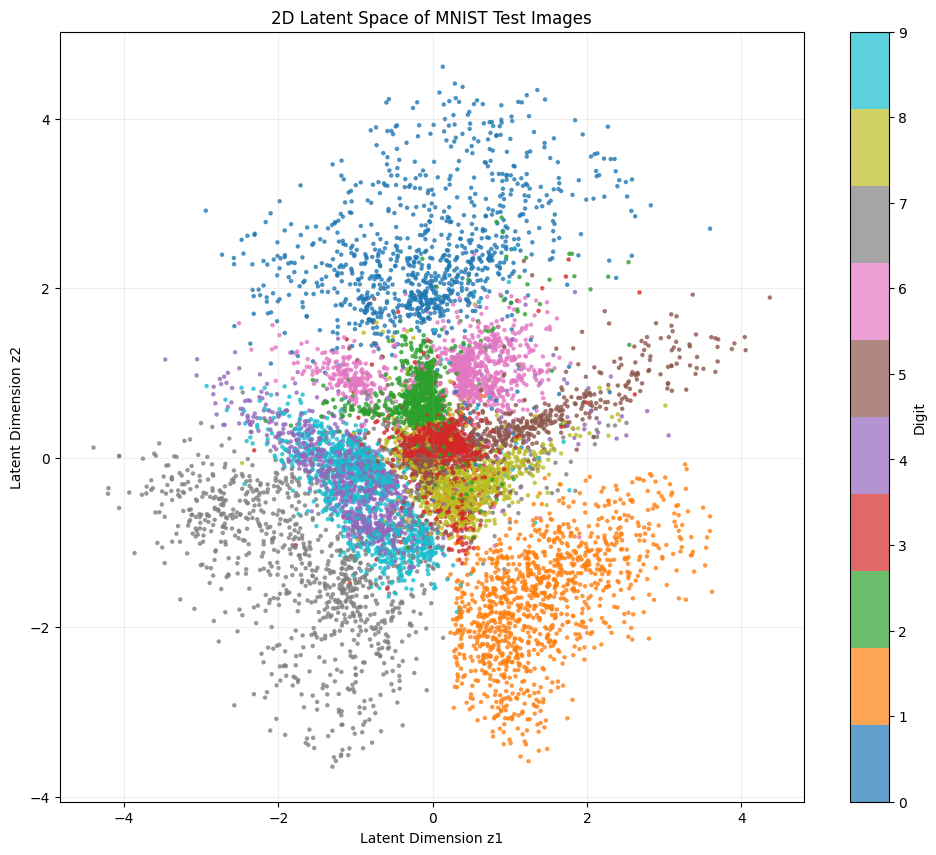

In [ ]:
# Plot the 2D latent space

plt.figure(figsize=(12, 10))

scatter = plt.scatter(
    z_mean_test[:, 0],
    z_mean_test[:, 1],
    c=y_test,
    cmap="tab10",
    s=5,
    alpha=0.7
)

plt.colorbar(
    scatter,
    ticks=range(10),
    label="Digit"
)

plt.xlabel("Latent Dimension z1")
plt.ylabel("Latent Dimension z2")
plt.title("2D Latent Space of MNIST Test Images")

plt.grid(alpha=0.2)
plt.show()

## Interpretation of the Latent Space

The latent-space plot shows that the VAE learns a structured representation of handwritten digits.

Images belonging to similar digit classes tend to appear closer together in the latent space.

However, the clusters may not be completely separated because some handwritten digits have similar shapes.

For example, digits such as 3 and 8 or 4 and 9 can have similar visual characteristics, so their latent representations may partially overlap.

## Generating Digits from the Latent Space

The decoder can generate a digit when it receives a point from the 2-dimensional latent space.

A grid of points is selected between approximately -3 and +3 for both latent dimensions.

Each point is passed through the decoder to generate a 28 × 28 digit image.

This allows us to observe how generated digits change as we move through the latent space.

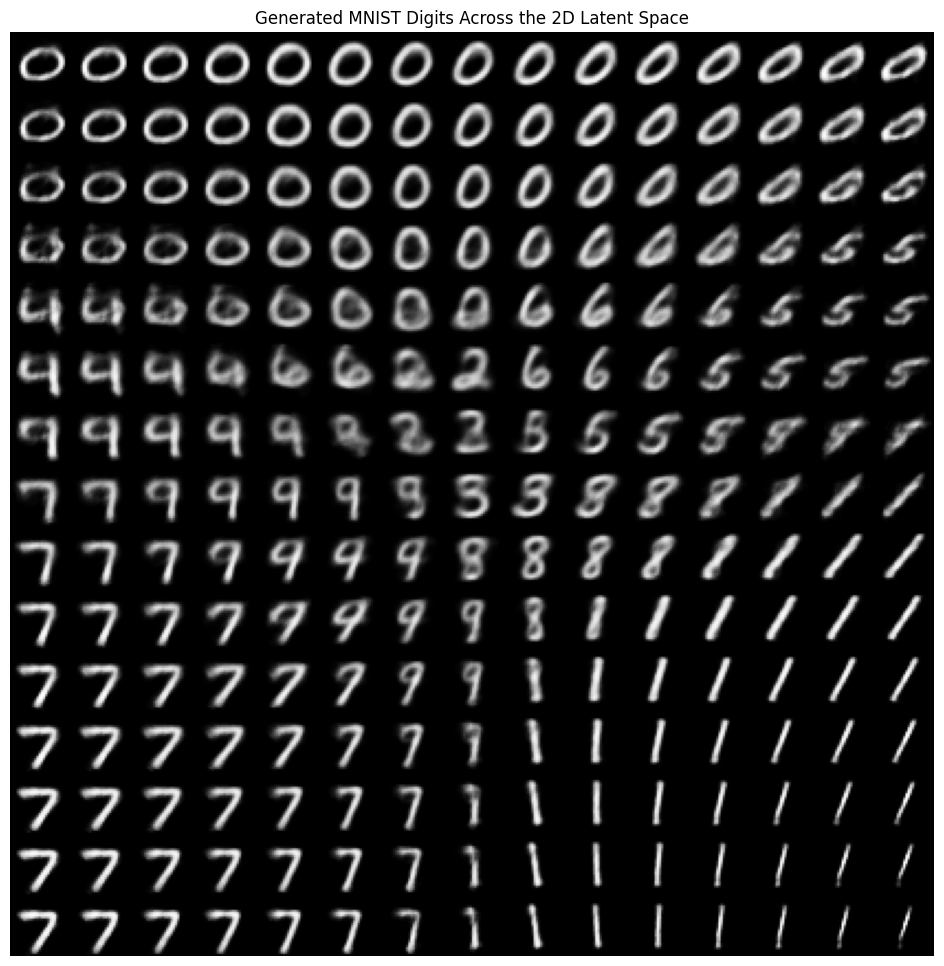

In [ ]:
# Generate digits from points across the latent space

grid_size = 15

z1_values = np.linspace(-3, 3, grid_size)
z2_values = np.linspace(3, -3, grid_size)

figure = np.zeros(
    (28 * grid_size, 28 * grid_size)
)

for i, z2 in enumerate(z2_values):

    for j, z1 in enumerate(z1_values):

        z_sample = np.array([[z1, z2]])

        decoded = decoder.predict(
            z_sample,
            verbose=0
        )

        digit = decoded[0].reshape(28, 28)

        figure[
            i * 28:(i + 1) * 28,
            j * 28:(j + 1) * 28
        ] = digit

plt.figure(figsize=(12, 12))

plt.imshow(
    figure,
    cmap="gray"
)

plt.axis("off")
plt.title(
    "Generated MNIST Digits Across the 2D Latent Space"
)

plt.show()

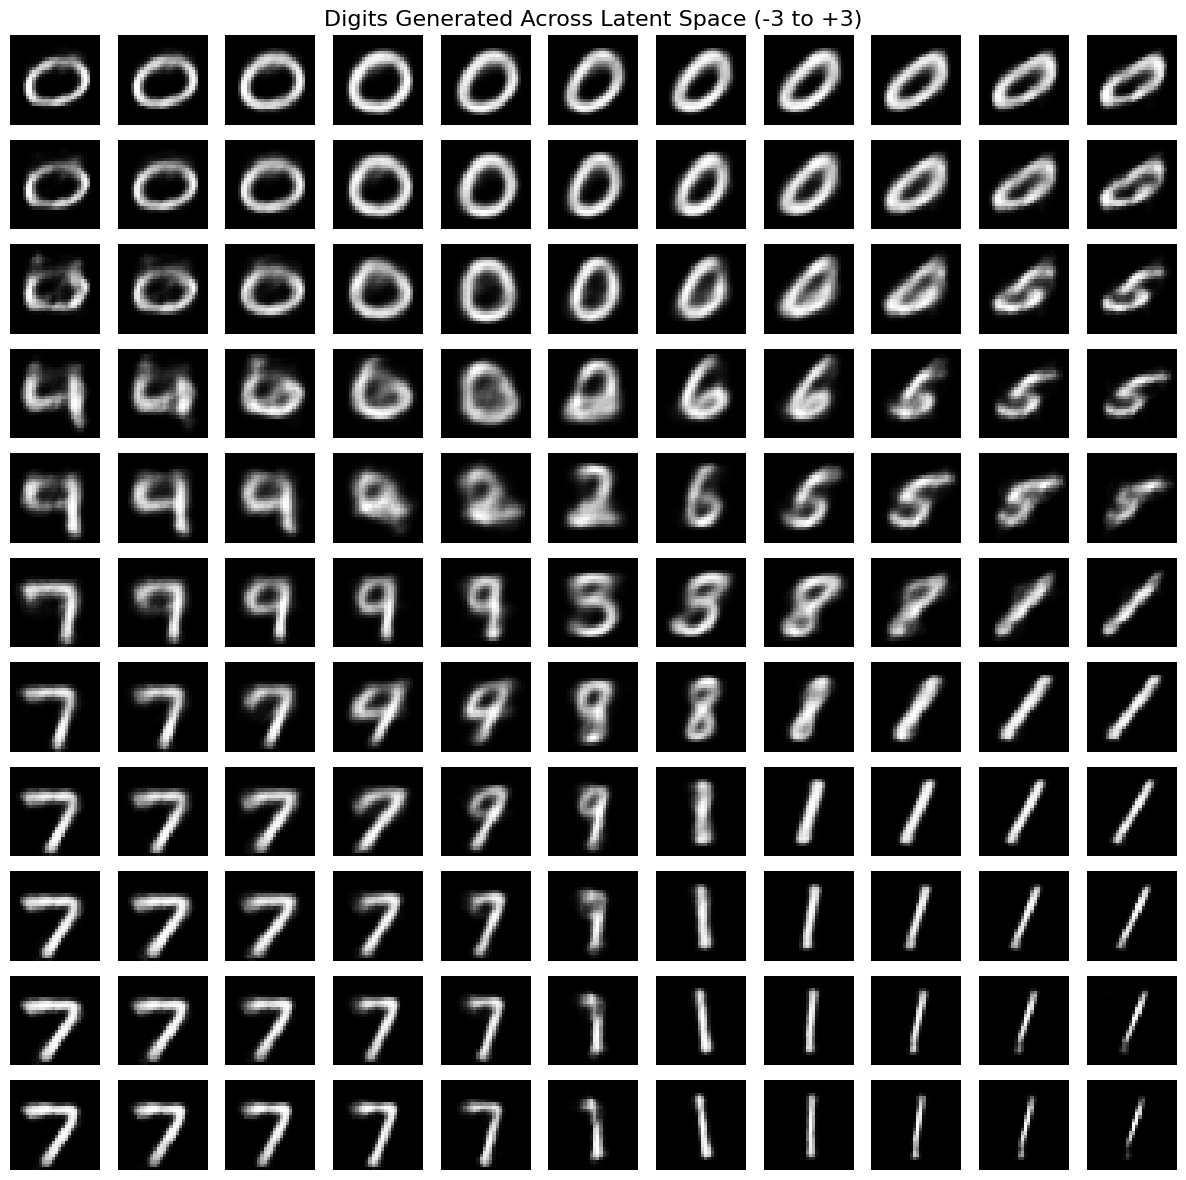

In [ ]:
# Display generated digits with latent-space coordinates

n = 11

z1_values = np.linspace(-3, 3, n)
z2_values = np.linspace(3, -3, n)

plt.figure(figsize=(12, 12))

for i, z2 in enumerate(z2_values):

    for j, z1 in enumerate(z1_values):

        z_sample = np.array([[z1, z2]])

        decoded = decoder.predict(
            z_sample,
            verbose=0
        )

        digit = decoded[0].reshape(28, 28)

        ax = plt.subplot(n, n, i * n + j + 1)

        ax.imshow(
            digit,
            cmap="gray"
        )

        ax.axis("off")

plt.suptitle(
    "Digits Generated Across Latent Space (-3 to +3)",
    fontsize=16
)

plt.tight_layout()
plt.show()

## Generating New Digits from Random Latent Points

Because the VAE has learned a structured latent space, new images can be generated by selecting random points from the latent distribution and passing them through the decoder.

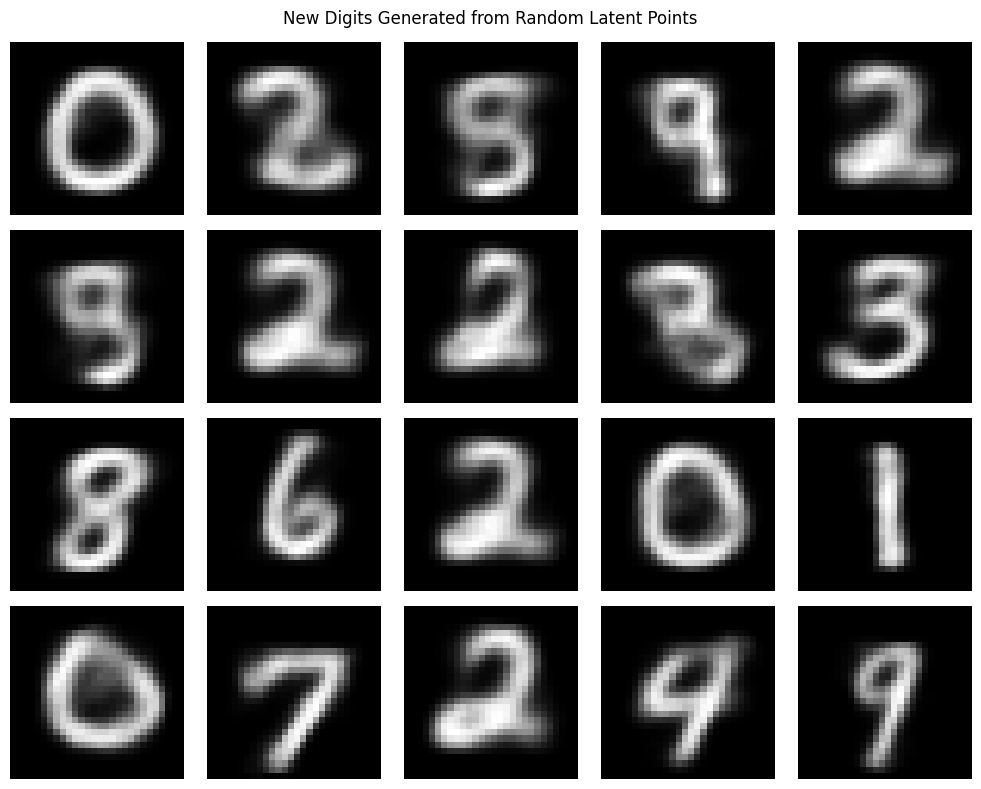

In [ ]:
# Generate new random latent points

num_new_images = 20

random_latent_points = np.random.normal(
    size=(num_new_images, latent_dim)
)

generated_images = decoder.predict(
    random_latent_points,
    verbose=0
)

plt.figure(figsize=(10, 8))

for i in range(num_new_images):

    plt.subplot(4, 5, i + 1)

    plt.imshow(
        generated_images[i].reshape(28, 28),
        cmap="gray"
    )

    plt.axis("off")

plt.suptitle("New Digits Generated from Random Latent Points")

plt.tight_layout()
plt.show()

## Original and Reconstructed Images

To evaluate the reconstruction ability of the VAE, test images are passed through the complete encoder-decoder pipeline.

The original images are compared with their reconstructed versions.

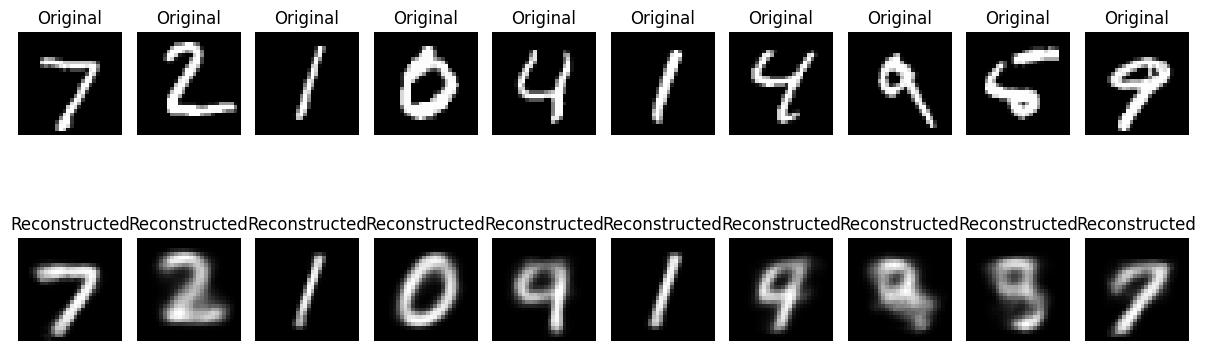

In [ ]:
# Reconstruct test images

z_mean, z_log_var = encoder.predict(
    x_test[:10],
    verbose=0
)

z = Sampling()((z_mean, z_log_var))

reconstructed_images = decoder.predict(
    z,
    verbose=0
)

plt.figure(figsize=(12, 5))

for i in range(10):

    # Original
    ax = plt.subplot(2, 10, i + 1)

    plt.imshow(
        x_test[i].reshape(28, 28),
        cmap="gray"
    )

    plt.title("Original")
    plt.axis("off")

    # Reconstructed
    ax = plt.subplot(2, 10, i + 11)

    plt.imshow(
        reconstructed_images[i].reshape(28, 28),
        cmap="gray"
    )

    plt.title("Reconstructed")
    plt.axis("off")

plt.tight_layout()
plt.show()

## Observations

### 1. Do similar digits form clusters?

Yes, similar digits generally form clusters in the 2D latent space. The VAE learns important features such as the shape, curves, thickness, and structure of handwritten digits. Images having similar features are represented by nearby points in the latent space. Therefore, different handwritten versions of the same digit tend to appear close to each other and form groups.

This can be observed in the 2D scatter plot, where points belonging to similar digit classes are concentrated in particular regions. This shows that the VAE has learned meaningful patterns and relationships from the MNIST dataset.

### 2. Are the clusters clearly separated?

The clusters are partially separated, but they are not completely distinct. Some digit classes form clear groups, while other groups overlap with each other. This happens because different handwritten digits can have similar shapes and visual features.

For example, some handwritten versions of 3 and 8 or 4 and 9 may have similar structures. Because of these similarities, their representations can appear close to each other in the latent space. Therefore, the plot shows meaningful clustering, although the boundaries between all digit classes are not perfectly separated.

### 3. How do generated digits change when moving gradually through the latent space?

When we move gradually from one point to another in the latent space, the generated digits also change gradually. The decoder uses the latent coordinates to generate the digit image, so nearby points generally produce visually similar images.

As we move across the latent-space grid, features such as the shape, size, thickness, curves, and writing style of the digits slowly change. A digit can gradually transform into another digit instead of changing suddenly. This shows that the VAE has learned a continuous representation of the MNIST data.

The generated digit grid using points approximately from -3 to +3 demonstrates how the appearance of the generated digits changes across different regions of the latent space.

### 4. Does the transition between generated images appear smooth?

Yes, the transition between the generated images generally appears smooth. When nearby points in the latent space are decoded, the resulting images tend to have similar shapes and characteristics. As the latent coordinates change gradually, the generated digits also change gradually rather than producing completely unrelated images.

This smooth transition shows that the VAE has learned a continuous and structured latent space. The decoder can generate meaningful intermediate images between different regions of the latent space. The generated image grid demonstrates this by showing gradual changes in digit shape and appearance as we move across the selected latent points.

# Conclusion

In this assignment, a Variational Autoencoder (VAE) was successfully implemented using the MNIST handwritten digit dataset. The model used an encoder, a 2-dimensional latent space, a sampling layer, and a decoder to learn the important features of the handwritten digits.

The VAE was trained using reconstruction loss and KL divergence loss. After training, the test images were passed through the encoder and visualised in a 2D latent space. The plot showed that similar digits generally formed clusters, although some overlap was present between digits with similar shapes.

Points from approximately -3 to +3 in the latent space were also decoded to generate new digit images. The generated images showed gradual changes as the latent coordinates changed, demonstrating that the VAE learned a continuous and meaningful latent representation.

Overall, this experiment helped demonstrate how Variational Autoencoders can be used to learn, reconstruct, and generate new handwritten digit images from a structured latent space.